Title: Toronto Motor Vehicle Collisions — Insights Summary (Group 4)

Goal: Summarize key trends found in EDA and translate them into actionable insights for decision-makers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)

DATA_PATH = "../data/cleaned/Traffic_Collisions_Cleaned.csv"
df = pd.read_csv(DATA_PATH)

df["OCC_DATE"] = pd.to_datetime(df["OCC_DATE"], errors="coerce")

print("Shape:", df.shape)
df.head()

Shape: (772516, 23)


,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,FTR_COLLISIONS,PD_COLLISIONS,HOOD_158,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,1,GO-20148000028,2014-01-01 05:00:00,January,Wednesday,2014,17,D53,0,NO,YES,NO,099,Mount Pleasant East (99),-79.377616,43.701225,YES,NO,NO,NO,NO,-8.836276e+06,5.419322e+06
1,2,GO-20148004875,2014-01-01 05:00:00,January,Wednesday,2014,14,D32,0,NO,NO,YES,105,Lawrence Park North (105),-79.397589,43.726091,YES,NO,NO,NO,NO,-8.838499e+06,5.423152e+06
2,3,GO-20141260499,2014-01-01 05:00:00,January,Wednesday,2014,2,NSA,0,YES,NO,NO,NSA,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
3,4,GO-20141260663,2014-01-01 05:00:00,January,Wednesday,2014,3,NSA,0,NO,NO,YES,NSA,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09
4,5,GO-20141261162,2014-01-01 05:00:00,January,Wednesday,2014,5,NSA,0,YES,NO,NO,NSA,NSA,0.000000,0.000000,YES,NO,NO,NO,NO,6.327780e-09,5.664924e-09


In [12]:
# Remove NSA from Division and Neighbourhood
df_clean = df.copy()

df_clean = df_clean[df_clean["DIVISION"].astype(str).str.upper() != "NSA"]
df_clean = df_clean[df_clean["NEIGHBOURHOOD_158"].astype(str).str.upper() != "NSA"]

# Remove invalid coordinates (0,0)
df_clean = df_clean[(df_clean["LAT_WGS84"] != 0) & (df_clean["LONG_WGS84"] != 0)]

print("Original Shape:", df.shape)
print("Clean Shape (No NSA + valid coords):", df_clean.shape)

Original Shape: (772516, 23)
Clean Shape (No NSA + valid coords): (646447, 23)


In [13]:
top_div = (
    df_clean.groupby("DIVISION")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_div

DIVISION
D42    57696
D32    56971
D41    52928
D33    48721
D55    47791
D53    43066
D14    42106
D43    41566
D22    41388
D31    37222
dtype: int64

## Highest Collision Divisions (Excluding NSA)

Division D42 records the highest number of collisions, followed closely by D32 and D41.

This indicates concentrated collision activity within specific policing divisions.

In [14]:
top_neigh = (
    df_clean.groupby("NEIGHBOURHOOD_158")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_neigh

NEIGHBOURHOOD_158
Wexford/Maryvale (119)                         18988
West Humber-Clairville (1)                     15622
York University Heights (27)                   12757
St Lawrence-East Bayfront-The Islands (166)    10862
Dorset Park (126)                              10764
Etobicoke City Centre (159)                    10446
Banbury-Don Mills (42)                         10376
Milliken (130)                                 10116
Yorkdale-Glen Park (31)                         9996
Yonge-Bay Corridor (170)                        9681
dtype: int64

## Highest Collision Neighbourhoods (Excluding NSA)

Wexford/Maryvale (119) records the highest number of collisions, followed by West Humber-Clairville (1) and York University Heights (27).

These neighbourhoods represent high-density collision hotspots.

In [15]:
summary = pd.DataFrame({
    "Metric": [
        "Total Collisions (No NSA)",
        "Total Fatalities",
        "Injury Collisions (YES)",
        "Fail to Remain (YES)",
        "Property Damage (YES)"
    ],
    "Value": [
        len(df_clean),
        df_clean["FATALITIES"].sum(),
        (df_clean["INJURY_COLLISIONS"] == "YES").sum(),
        (df_clean["FTR_COLLISIONS"] == "YES").sum(),
        (df_clean["PD_COLLISIONS"] == "YES").sum()
    ]
})
summary

,Metric,Value
0,Total Collisions (No NSA),646447
1,Total Fatalities,636
2,Injury Collisions (YES),91774
3,Fail to Remain (YES),113752
4,Property Damage (YES),455395


This table summarizes the key collision outcomes after excluding NSA and invalid coordinates

In [16]:
coll_by_year = df_clean.groupby("OCC_YEAR").size().sort_index()
coll_by_year

OCC_YEAR
2014    53611
2015    58853
2016    62010
2017    64401
2018    64077
2019    64987
2020    36415
2021    35699
2022    48707
2023    57149
2024    58716
2025    41822
dtype: int64

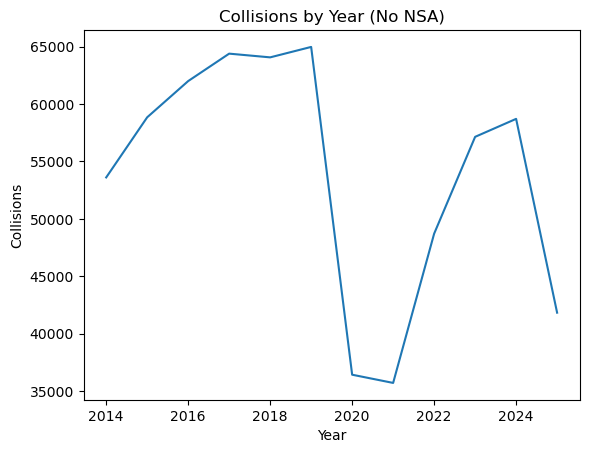

In [17]:
plt.figure()
coll_by_year.plot(kind="line")
plt.title("Collisions by Year (No NSA)")
plt.xlabel("Year")
plt.ylabel("Collisions")
plt.show()

## Collision Trend by Year

Collisions increased steadily from 2014 to 2019.  
A significant drop is observed in 2020 and 2021, followed by recovery from 2022 onward.  
The lower value in 2025 likely represents partial-year data.

This trend indicates the impact of external factors during 2020–2021 and a return to pre-pandemic levels afterward.

In [18]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
df_clean["OCC_MONTH"] = pd.Categorical(df_clean["OCC_MONTH"], categories=month_order, ordered=True)

coll_by_month = df_clean.groupby("OCC_MONTH").size()
coll_by_month

C:\Users\sumit\AppData\Local\Temp\ipykernel_33840\2105061229.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coll_by_month = df_clean.groupby("OCC_MONTH").size()


OCC_MONTH
January      55356
February     54453
March        50673
April        46802
May          54499
June         56479
July         54833
August       54561
September    56665
October      54046
November     54330
December     53750
dtype: int64

## Collision Distribution by Month

Collisions are relatively stable throughout the year, with slight variation.  
September records the highest collision count, while April shows comparatively lower activity.

This suggests moderate seasonal influence but no extreme seasonal concentration.

In [19]:
coll_by_hour = df_clean.groupby("OCC_HOUR").size().sort_index()
coll_by_hour

OCC_HOUR
0      7772
1      6653
2      6292
3      6043
4      4528
5      5741
6     13085
7     20437
8     36866
9     34167
10    32810
11    38378
12    42983
13    42401
14    45826
15    53537
16    51451
17    53109
18    44750
19    31530
20    22626
21    18763
22    15064
23    11635
dtype: int64

## Collision Distribution by Hour

Collisions are lowest during late-night hours (00:00–05:00).  
A sharp increase begins around 06:00, peaking between 15:00–17:00.

This indicates that afternoon peak traffic hours represent the highest collision risk period.

In [20]:
severity = pd.DataFrame({
    "Type": ["Injury (YES)", "Fatalities (>0)", "Fail to Remain (YES)", "Property Damage (YES)"],
    "Count": [
        (df_clean["INJURY_COLLISIONS"] == "YES").sum(),
        (df_clean["FATALITIES"] > 0).sum(),
        (df_clean["FTR_COLLISIONS"] == "YES").sum(),
        (df_clean["PD_COLLISIONS"] == "YES").sum()
    ]
})

severity["% of Total"] = (severity["Count"] / len(df_clean)) * 100
severity

,Type,Count,% of Total
0,Injury (YES),91774,14.196678
1,Fatalities (>0),621,0.096064
2,Fail to Remain (YES),113752,17.596493
3,Property Damage (YES),455395,70.445837


## Collision Outcome Analysis

Property Damage collisions form the majority of reported cases (approximately 70%).  
Fail-to-Remain cases account for around 17%, while Injury collisions represent roughly 14%.  
Fatal collisions are extremely rare compared to overall volume.

This highlights that most incidents are non-fatal but still significant in volume.

In [21]:
invol_cols = ["AUTOMOBILE","MOTORCYCLE","PASSENGER","BICYCLE","PEDESTRIAN"]
involvement = pd.DataFrame({
    "Involvement Type": invol_cols,
    "Count": [(df_clean[c] == "YES").sum() for c in invol_cols]
}).sort_values("Count", ascending=False)

involvement

,Involvement Type,Count
0,AUTOMOBILE,638695
2,PASSENGER,52608
4,PEDESTRIAN,17686
3,BICYCLE,11633
1,MOTORCYCLE,3992


## Involvement Type Analysis

Automobiles dominate total collision involvement by a large margin.  
Passenger, pedestrian, bicycle, and motorcycle involvement appear significantly lower in comparison.

This suggests that private vehicle usage plays a central role in collision frequency.

# Final Insights Summary

1. Total collisions (excluding NSA) are 646,447 across the dataset period.

2. Collision trends peaked between 2016–2019, dropped sharply in 2020–2021, and recovered post-2022.

3. September shows the highest collision volume among months.

4. Peak collision hours occur between 3 PM and 5 PM, indicating high risk during afternoon traffic.

5. Property Damage collisions account for the majority (70%+), followed by Fail to Remain (17%) and Injury collisions (14%).

6. Division D42 records the highest number of collisions.

7. Wexford/Maryvale (119) is the highest collision neighbourhood.

8. Automobiles dominate involvement types, significantly exceeding pedestrian and bicycle involvement.